<a href="https://colab.research.google.com/github/noambar2910/Homework2/blob/main/noambar_homework2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework Assignment 2  
# Regression and Classification: Error Analysis

**Student name:** Noam Bar  
**Student ID:** 322333493  
**Course:** Introduction to Data Science  
**Instructor:** Dr. Uri Itai  
**Teaching Assistant:** Gabriella Vagner  

This notebook follows the assignment instructions: regression error analysis, comparison of regression models, classification error analysis, threshold analysis, and final reflection.

The dataset used is the online sales dataset from Assignment 1: `Shop Direct Sale Data For Research.csv`.

## 0. Imports and Data Loading

The notebook loads the dataset directly from GitHub so that it can run without manually uploading the CSV file.
If the GitHub link is unavailable, the code also tries to load the CSV from the local folder.

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from scipy.stats import skew, kurtosis

from sklearn.model_selection import KFold, StratifiedKFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score, fbeta_score,
    matthews_corrcoef, roc_auc_score, roc_curve,
    classification_report
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

DATA_URL = "https://raw.githubusercontent.com/noambar2910/Homework2/refs/heads/main/Shop%20Direct%20Sale%20Data%20For%20Research.csv"

try:
    df = pd.read_csv(DATA_URL)
except Exception:
    df = pd.read_csv("Shop Direct Sale Data For Research.csv")

df.head()

,Order ID,Order Date,Customer Name,City,Country,State,Region,Segment,Category,Ship Mode,Sub-Category,Product Name,Quantity,Cost,Profit,Sales
0,1,1/1/2017,Ruby Patel,Stockholm,Sweden,Stockholm,North,Home Office,Office Supplies,Economy Plus,Paper,"Enermax Note Cards, Premium",3,9,36,45
1,2,1/3/2017,Summer Hayward,Southport,United Kingdom,England,North,Consumer,Furniture,Economy,Bookcases,"Dania Corner Shelving, Traditional",7,255,599,854
2,3,1/4/2017,Devin Huddleston,Valence,France,Auvergne-Rhône-Alpes,Central,Consumer,Office Supplies,Economy,Art,"Binney & Smith Sketch Pad, Easy-Erase",3,48,92,140
3,4,1/4/2017,Mary Parker,Birmingham,United Kingdom,England,North,Corporate,Office Supplies,Economy,Art,"Boston Markers, Easy-Erase",2,9,18,27
4,5,1/5/2017,Daniel Burke,Echirolles,France,Auvergne-Rhône-Alpes,Central,Home Office,Office Supplies,Priority,Art,"Binney & Smith Pencil Sharpener, Water Color",3,40,50,90


,Order ID,Order Date,Customer Name,City,Country,State,Region,Segment,Category,Ship Mode,Sub-Category,Product Name,Quantity,Cost,Profit,Sales
0,1,1/1/2017,Ruby Patel,Stockholm,Sweden,Stockholm,North,Home Office,Office Supplies,Economy Plus,Paper,"Enermax Note Cards, Premium",3,9,36,45
1,2,1/3/2017,Summer Hayward,Southport,United Kingdom,England,North,Consumer,Furniture,Economy,Bookcases,"Dania Corner Shelving, Traditional",7,255,599,854
2,3,1/4/2017,Devin Huddleston,Valence,France,Auvergne-Rhône-Alpes,Central,Consumer,Office Supplies,Economy,Art,"Binney & Smith Sketch Pad, Easy-Erase",3,48,92,140
3,4,1/4/2017,Mary Parker,Birmingham,United Kingdom,England,North,Corporate,Office Supplies,Economy,Art,"Boston Markers, Easy-Erase",2,9,18,27
4,5,1/5/2017,Daniel Burke,Echirolles,France,Auvergne-Rhône-Alpes,Central,Home Office,Office Supplies,Priority,Art,"Binney & Smith Pencil Sharpener, Water Color",3,40,50,90


In [47]:
df.shape

(4115, 16)

(4115, 16)

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4115 entries, 0 to 4114
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Order ID       4115 non-null   int64 
 1   Order Date     4115 non-null   object
 2   Customer Name  4115 non-null   object
 3   City           4115 non-null   object
 4   Country        4115 non-null   object
 5   State          4115 non-null   object
 6   Region         4115 non-null   object
 7   Segment        4115 non-null   object
 8   Category       4115 non-null   object
 9   Ship Mode      4115 non-null   object
 10  Sub-Category   4115 non-null   object
 11  Product Name   4115 non-null   object
 12  Quantity       4115 non-null   int64 
 13  Cost           4115 non-null   int64 
 14  Profit         4115 non-null   int64 
 15  Sales          4115 non-null   int64 
dtypes: int64(5), object(11)
memory usage: 514.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4115 entries, 0 

## 1. Problem Formulation

The assignment requires both regression and classification error analysis.

### Regression task
The regression target is:

`Sales`

The goal is to predict the sales value of an online transaction.

### Classification task
The dataset does not include a ready binary classification label.  
Therefore, the classification task is defined from an existing variable in the dataset:

`HighSales = 1` if `Sales` is above the median sales value, and `0` otherwise.

This formulation creates a business-oriented classification question:  
**Can we identify whether a transaction is expected to be high-sales or not?**

To avoid target leakage, the original `Sales` column is not used as an input feature for the classification model.  
The `Profit` column is also excluded from both tasks because in this dataset:

`Sales = Cost + Profit`

Using `Profit` to predict `Sales` would make the task artificially easy and would not reflect a realistic modeling problem.

In [49]:
# Convert order date to datetime
df["Order Date"] = pd.to_datetime(df["Order Date"])

# Verify the deterministic relation Sales = Cost + Profit
(df["Sales"] == df["Cost"] + df["Profit"]).mean()

np.float64(1.0)

np.float64(1.0)

In [50]:
# Create a time-based numeric feature for modeling
df["OrderDateOrdinal"] = df["Order Date"].map(pd.Timestamp.toordinal)

# Classification target: HighSales based on the median
sales_median = df["Sales"].median()
df["HighSales"] = (df["Sales"] > sales_median).astype(int)

sales_median, df["HighSales"].value_counts(normalize=True)

(120.0,
 HighSales
 0    0.500122
 1    0.499878
 Name: proportion, dtype: float64)

(120.0,
 HighSales
 0    0.500122
 1    0.499878
 Name: proportion, dtype: float64)

## 2. Cross-Validation Strategy

All analyses are conducted using k-fold cross-validation, as required.

I use **k = 5**.

Justification:
- The dataset contains 4,115 observations, which is large enough to split into 5 folds.
- 5-fold cross-validation gives a reasonable balance between bias and variance.
- A larger k, such as 10, would require more model training runs and increase computational cost.
- A smaller k, such as 2 or 3, may produce less stable evaluation results.

For regression, regular `KFold` is used.  
For classification, `StratifiedKFold` is used in order to preserve the class distribution in each fold.

In [51]:
RANDOM_STATE = 42
K = 5

kfold = KFold(n_splits=K, shuffle=True, random_state=RANDOM_STATE)
skfold = StratifiedKFold(n_splits=K, shuffle=True, random_state=RANDOM_STATE)

## 3. Feature Set

All models in each task are trained on the same feature set, as required.

Excluded columns:
- `Order ID`: technical identifier.
- `Customer Name`: personal/customer identifier with high cardinality.
- `Order Date`: replaced by numeric date representation.
- `Sales`: target variable.
- `Profit`: excluded to avoid target leakage because `Sales = Cost + Profit`.
- `HighSales`: classification target.

In [52]:
excluded_cols = ["Order ID", "Customer Name", "Order Date", "Sales", "Profit", "HighSales"]

feature_cols = [col for col in df.columns if col not in excluded_cols]
feature_cols

['City',
 'Country',
 'State',
 'Region',
 'Segment',
 'Category',
 'Ship Mode',
 'Sub-Category',
 'Product Name',
 'Quantity',
 'Cost',
 'OrderDateOrdinal']

['City',
 'Country',
 'State',
 'Region',
 'Segment',
 'Category',
 'Ship Mode',
 'Sub-Category',
 'Product Name',
 'Quantity',
 'Cost',
 'OrderDateOrdinal']

In [53]:
X = df[feature_cols].copy()
y_reg = df["Sales"].copy()
y_clf = df["HighSales"].copy()

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

numeric_features, categorical_features

(['Quantity', 'Cost', 'OrderDateOrdinal'],
 ['City',
  'Country',
  'State',
  'Region',
  'Segment',
  'Category',
  'Ship Mode',
  'Sub-Category',
  'Product Name'])

(['Quantity', 'Cost', 'OrderDateOrdinal'],
 ['City',
  'Country',
  'State',
  'Region',
  'Segment',
  'Category',
  'Ship Mode',
  'Sub-Category',
  'Product Name'])

In [54]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Part A — Regression Error Analysis

## 4. Regression Models

The assignment requires at least:
1. Linear Regression
2. Decision Tree Regressor
3. Ensemble model

The ensemble model used here is Random Forest Regressor.

All models use the same feature set and the same cross-validation splits.

In [10]:
regression_models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(
        random_state=RANDOM_STATE,
        max_depth=8
    ),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

regression_predictions = {}
regression_metrics = []

for name, model in regression_models.items():
    pipe = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", model)
    ])

    y_pred = cross_val_predict(pipe, X, y_reg, cv=kfold, n_jobs=-1)
    residuals = y_reg - y_pred

    regression_predictions[name] = y_pred

    mse = mean_squared_error(y_reg, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_reg, y_pred)
    r2 = r2_score(y_reg, y_pred)

    regression_metrics.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    })

reg_metrics_df = pd.DataFrame(regression_metrics).sort_values("RMSE")
reg_metrics_df

,Model,MAE,MSE,RMSE,R2
2,Random Forest Regressor,107.455738,65498.281158,255.926320,0.749580
1,Decision Tree Regressor,128.936152,77327.297303,278.077862,0.704354
0,Linear Regression,183.615294,99524.090018,315.474389,0.619489


### Regression model selection for detailed error analysis

The model with the lowest RMSE is selected for the detailed residual and error analysis below.

In [11]:
best_reg_model_name = reg_metrics_df.iloc[0]["Model"]
best_reg_model_name

'Random Forest Regressor'

In [12]:
y_reg_pred = regression_predictions[best_reg_model_name]
residuals = y_reg - y_reg_pred
abs_errors = np.abs(residuals)

reg_error_df = df.copy()
reg_error_df["PredictedSales"] = y_reg_pred
reg_error_df["Residual"] = residuals
reg_error_df["AbsoluteError"] = abs_errors

reg_error_df[["Sales", "PredictedSales", "Residual", "AbsoluteError"]].head()

,Sales,PredictedSales,Residual,AbsoluteError
0,45,51.59,-6.59,6.59
1,854,796.73,57.27,57.27
2,140,73.10,66.90,66.90
3,27,26.53,0.47,0.47
4,90,76.14,13.86,13.86


## 5. Residual Analysis

Residual is defined as:

`Residual = y - ŷ`

This section checks whether residuals are centered around zero, whether systematic patterns appear, and whether there is evidence of heteroscedasticity.

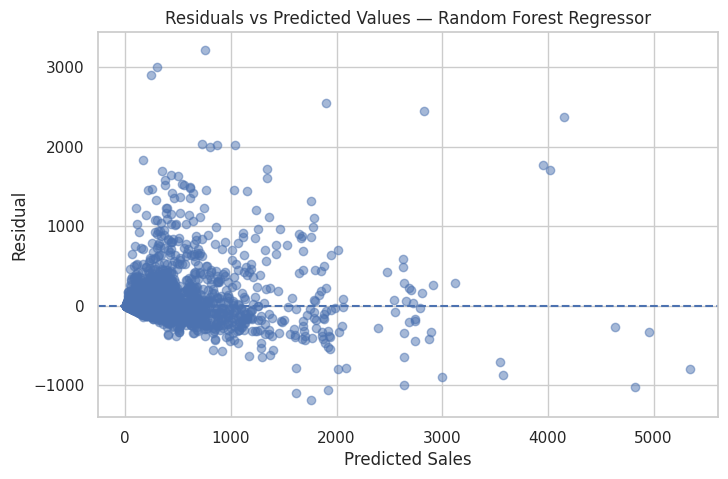

In [13]:
plt.figure(figsize=(8, 5))
plt.scatter(reg_error_df["PredictedSales"], reg_error_df["Residual"], alpha=0.5)
plt.axhline(0, linestyle="--")
plt.title(f"Residuals vs Predicted Values — {best_reg_model_name}")
plt.xlabel("Predicted Sales")
plt.ylabel("Residual")
plt.show()

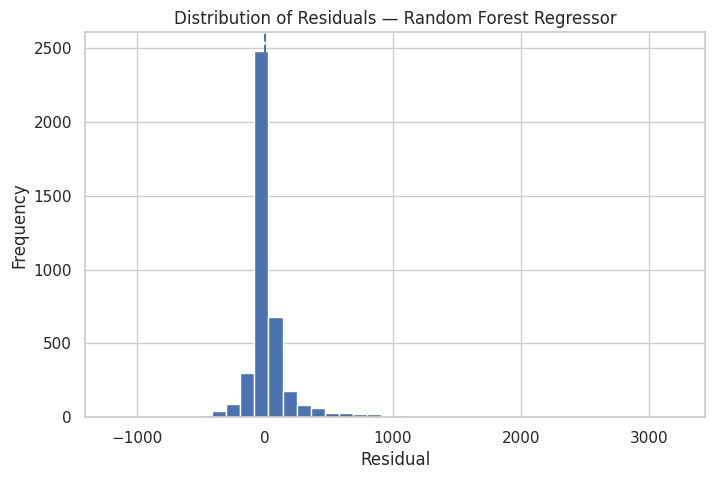

In [14]:
plt.figure(figsize=(8, 5))
plt.hist(reg_error_df["Residual"], bins=40)
plt.axvline(0, linestyle="--")
plt.title(f"Distribution of Residuals — {best_reg_model_name}")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

In [15]:
residual_summary = pd.DataFrame({
    "Mean residual": [reg_error_df["Residual"].mean()],
    "Median residual": [reg_error_df["Residual"].median()],
    "Residual std": [reg_error_df["Residual"].std()],
    "Skewness": [skew(reg_error_df["Residual"])],
    "Kurtosis": [kurtosis(reg_error_df["Residual"])]
})

residual_summary

,Mean residual,Median residual,Residual std,Skewness,Kurtosis
0,39.381235,-3.17,252.908963,4.381486,33.920434


### Residual interpretation

The residual plot should be examined for:
- Residuals centered around zero.
- Curved or structured patterns, which may indicate model misspecification.
- Increasing or decreasing spread of residuals, which may indicate heteroscedasticity.

If the histogram is not symmetric or has heavy tails, it suggests that some observations are much harder to predict than others.

## 6. Error as a Function of Features

This section checks whether the model errors depend on specific features.

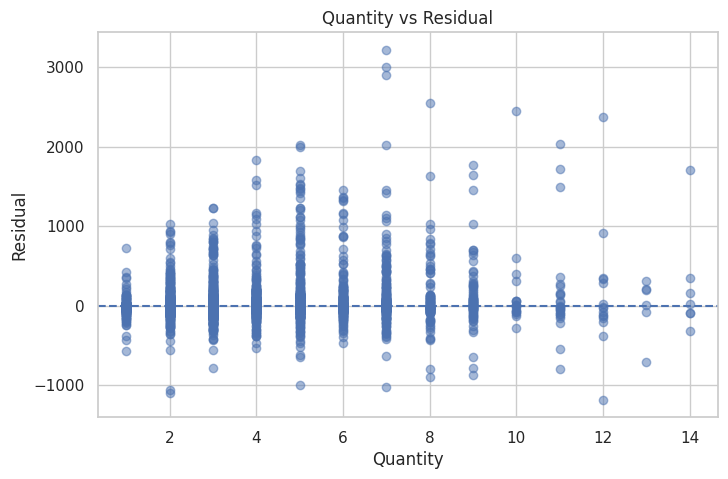

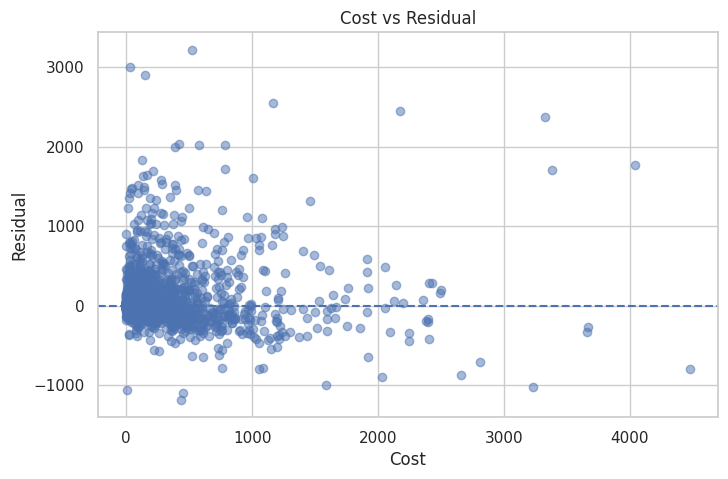

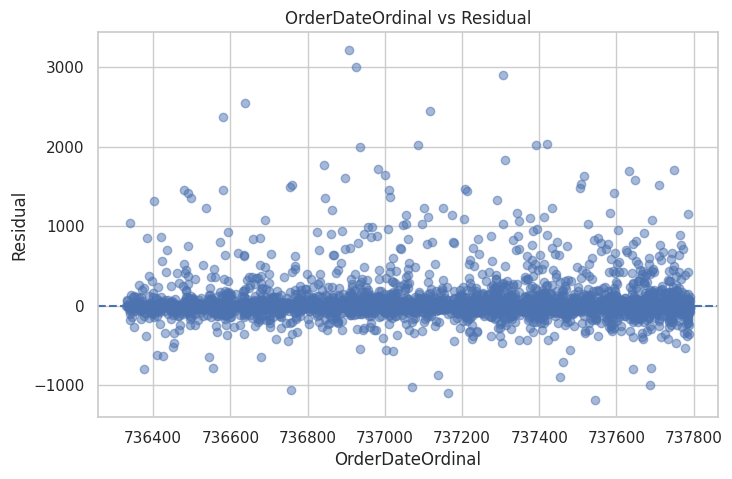

In [16]:
selected_numeric_features = ["Quantity", "Cost", "OrderDateOrdinal"]

for col in selected_numeric_features:
    plt.figure(figsize=(8, 5))
    plt.scatter(reg_error_df[col], reg_error_df["Residual"], alpha=0.5)
    plt.axhline(0, linestyle="--")
    plt.title(f"{col} vs Residual")
    plt.xlabel(col)
    plt.ylabel("Residual")
    plt.show()

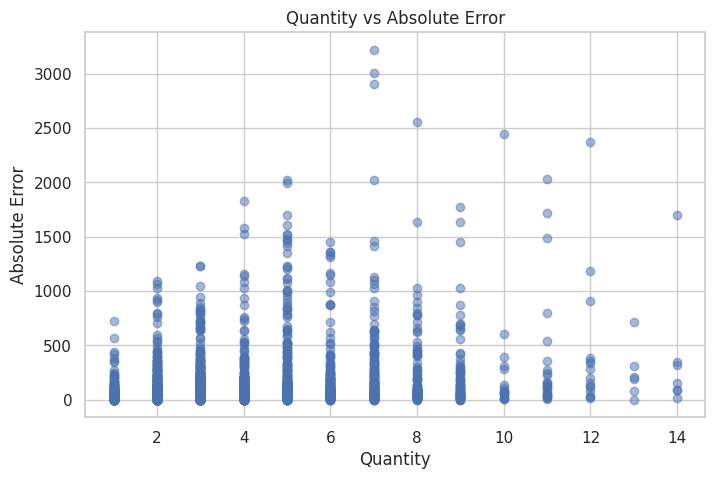

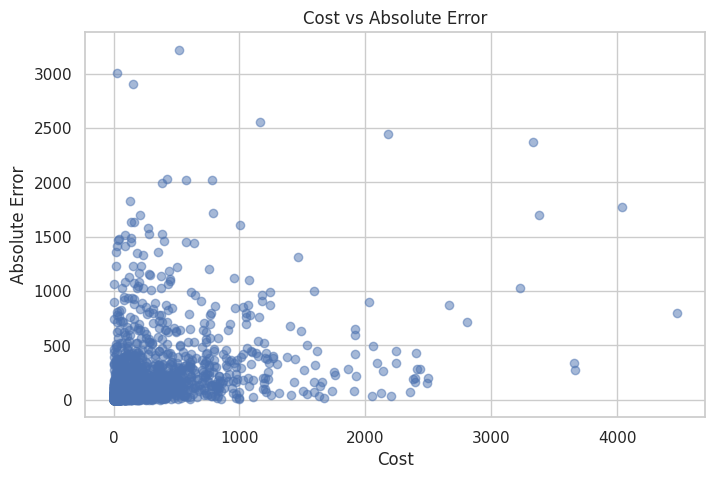

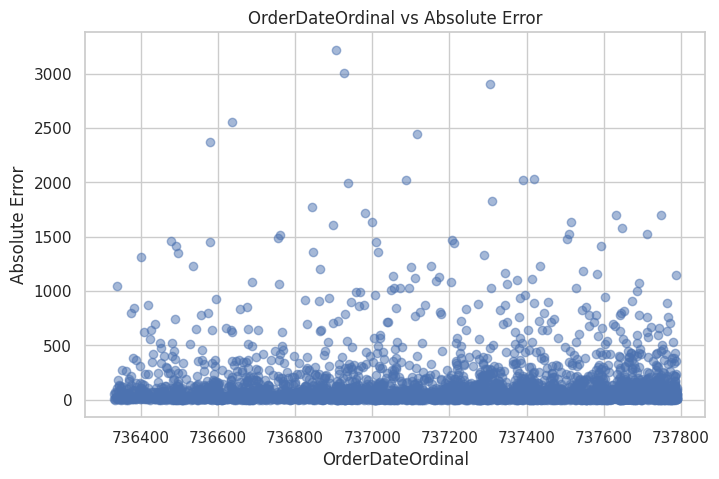

In [17]:
for col in selected_numeric_features:
    plt.figure(figsize=(8, 5))
    plt.scatter(reg_error_df[col], reg_error_df["AbsoluteError"], alpha=0.5)
    plt.title(f"{col} vs Absolute Error")
    plt.xlabel(col)
    plt.ylabel("Absolute Error")
    plt.show()

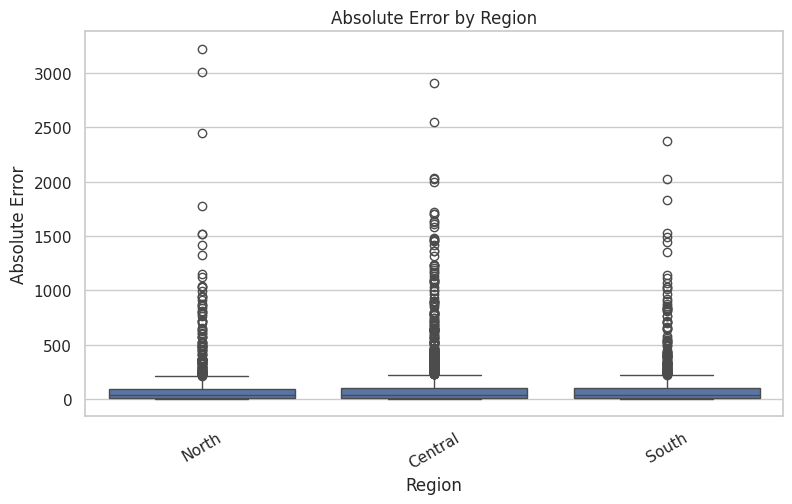

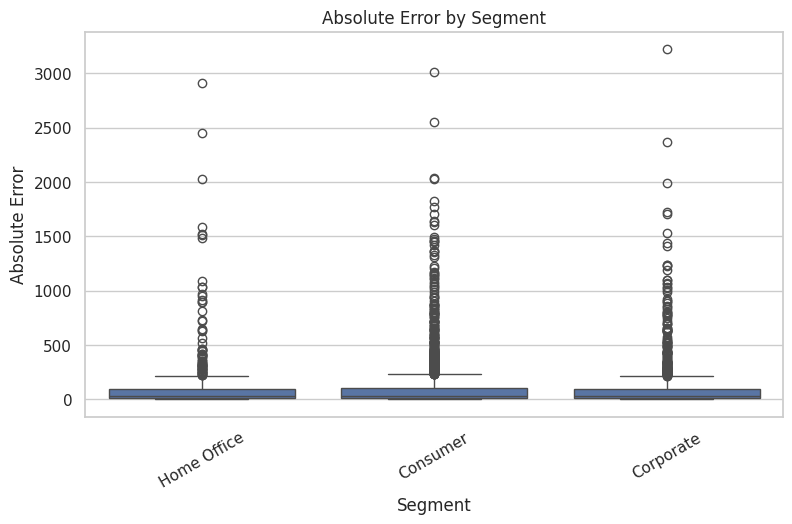

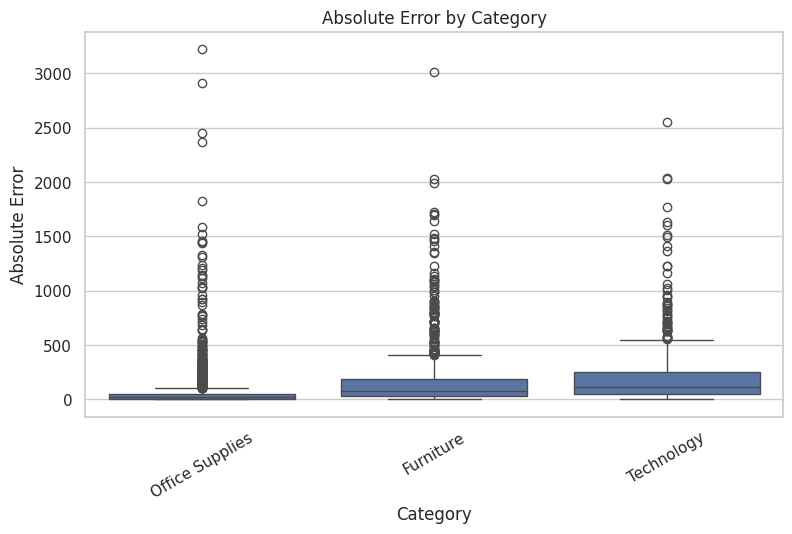

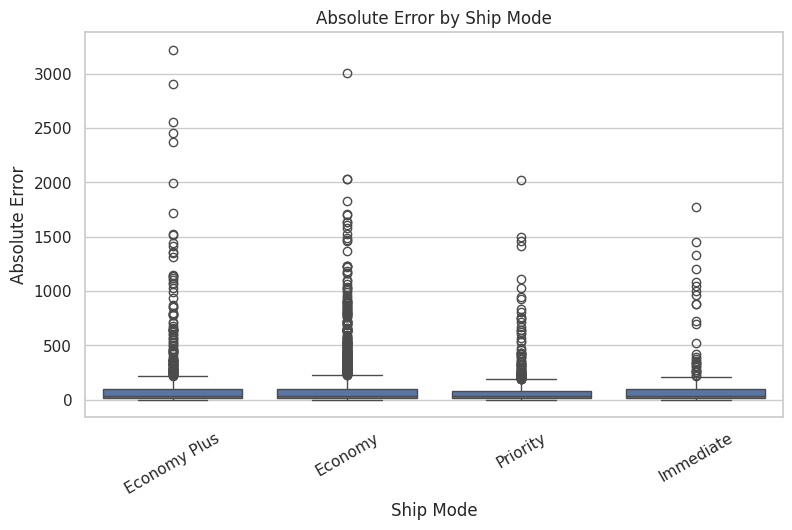

In [18]:
selected_categorical_features = ["Region", "Segment", "Category", "Ship Mode"]

for col in selected_categorical_features:
    plt.figure(figsize=(9, 5))
    sns.boxplot(data=reg_error_df, x=col, y="AbsoluteError")
    plt.title(f"Absolute Error by {col}")
    plt.xlabel(col)
    plt.ylabel("Absolute Error")
    plt.xticks(rotation=30)
    plt.show()

### Feature-dependent error interpretation

These plots help identify hidden subpopulations where the model performs worse.  
For example, if one category or segment has consistently higher absolute errors, it may mean that the model does not capture the behavior of that subgroup well.

## 7. Analysis of Extreme Regression Errors

The assignment requires identifying the top 5% largest absolute errors and analyzing these observations individually.

In [19]:
threshold_95 = reg_error_df["AbsoluteError"].quantile(0.95)
extreme_errors = reg_error_df[reg_error_df["AbsoluteError"] >= threshold_95].copy()

threshold_95, extreme_errors.shape

(np.float64(450.589), (206, 21))

In [20]:
extreme_errors_sorted = extreme_errors.sort_values("AbsoluteError", ascending=False)

cols_to_show = [
    "Order ID", "Order Date", "Country", "Region", "Segment", "Category",
    "Sub-Category", "Product Name", "Quantity", "Cost",
    "Sales", "PredictedSales", "Residual", "AbsoluteError"
]

extreme_errors_sorted[cols_to_show].head(20)

,Order ID,Order Date,Country,Region,Segment,Category,Sub-Category,Product Name,Quantity,Cost,Sales,PredictedSales,Residual,AbsoluteError
1186,1187,2018-08-01,United Kingdom,North,Corporate,Office Supplies,Appliances,"Hoover Stove, Red",7,519,3979,757.82,3221.18,3221.18
1259,1260,2018-08-20,United Kingdom,North,Consumer,Furniture,Chairs,"Harbour Creations Executive Leather Armchair, ...",7,28,3315,304.93,3010.07,3010.07
2359,2360,2019-09-03,France,Central,Home Office,Office Supplies,Appliances,"Hamilton Beach Refrigerator, Silver",7,153,3156,247.63,2908.37,2908.37
596,597,2017-11-05,France,Central,Consumer,Technology,Phones,"Cisco Smart Phone, with Caller ID",8,1163,4449,1896.22,2552.78,2552.78
1837,1838,2019-02-27,United Kingdom,North,Home Office,Office Supplies,Appliances,"KitchenAid Refrigerator, Black",10,2178,5274,2824.99,2449.01,2449.01
452,453,2017-09-08,Spain,South,Corporate,Office Supplies,Appliances,"Hamilton Beach Stove, Silver",12,3328,6517,4147.77,2369.23,2369.23
2773,2774,2019-12-26,France,Central,Consumer,Technology,Copiers,"Sharp Fax Machine, Laser",11,423,2764,729.54,2034.46,2034.46
2652,2653,2019-11-28,Spain,South,Consumer,Furniture,Bookcases,"Safco Classic Bookcase, Metal",7,781,3063,1036.11,2026.89,2026.89
1759,1760,2019-01-28,Germany,Central,Home Office,Technology,Phones,"Motorola Smart Phone, Cordless",5,577,2893,869.30,2023.70,2023.70
1301,1302,2018-08-30,Germany,Central,Corporate,Furniture,Tables,"Lesro Conference Table, Adjustable Height",5,388,2794,802.10,1991.90,1991.90


In [21]:
extreme_errors_sorted[cols_to_show].head(10).to_csv("top_extreme_regression_errors.csv", index=False)

### Discussion of extreme errors

The top 5% largest absolute errors should be interpreted carefully.

The table above displays individual high-error observations, including their order ID, date, country, region, segment, product information, actual sales, predicted sales, residual, and absolute error.  
Each row can be inspected separately in order to understand whether the error is connected to an unusual product, high cost, large quantity, rare category, or geographic/customer segment.

Possible explanations:
1. **Data quality issues** — unusual or suspicious values, such as very high cost or unusual product behavior.
2. **Model limitations** — the selected model may not fully capture complex interactions between product type, quantity, geography, and cost.
3. **Rare or exceptional cases** — large transactions, expensive products, or rare products may naturally be harder to predict.

Extreme errors should not be removed automatically. In business data, extreme transactions may be real and important.


## 8. Statistical Properties of Regression Errors

The assignment requires:
- MAE
- Standard deviation of residuals
- Skewness
- Kurtosis

In [22]:
reg_error_stats = pd.DataFrame({
    "Model": [best_reg_model_name],
    "MAE": [mean_absolute_error(y_reg, y_reg_pred)],
    "Residual STD": [reg_error_df["Residual"].std()],
    "Residual Skewness": [skew(reg_error_df["Residual"])],
    "Residual Kurtosis": [kurtosis(reg_error_df["Residual"])]
})

reg_error_stats

,Model,MAE,Residual STD,Residual Skewness,Residual Kurtosis
0,Random Forest Regressor,107.455738,252.908963,4.381486,33.920434


### Interpretation

- High residual standard deviation indicates that prediction errors vary widely.
- High kurtosis indicates heavy tails, meaning that extreme errors are more common than expected under a normal distribution.
- Skewness indicates whether the model tends to overpredict or underpredict in a systematic way.

## 9. Regression Model Discussion

This section compares the regression models critically according to the assignment requirements.

### Relative performance
The models are compared using MAE, MSE, RMSE, and R².  
MAE is useful because it expresses the average error in the original units of `Sales`.  
RMSE gives stronger weight to large errors, and therefore it is useful for detecting models that fail badly on extreme observations.  
R² describes the proportion of variation in `Sales` explained by the model.

### Model assumptions
Linear Regression assumes a linear relationship between the features and the target variable. It also assumes that residuals are approximately independent and that the residual variance is relatively constant across fitted values.  
The residual plots above are used to check whether the residuals are centered around zero, whether systematic patterns appear, and whether the spread of residuals changes as the predicted value increases.

If the residual plot shows curvature, the linearity assumption may not hold.  
If the residual spread increases for higher predicted values, this may indicate heteroscedasticity.  
The independence assumption is harder to verify directly from this dataset, but the use of unique order records reduces the risk of exact repeated observations.

Decision Tree and Random Forest can capture non-linear relationships and interactions between features, so they may perform better when the linearity assumption is not satisfied.

### Bias–variance trade-off
- Linear Regression usually has higher bias and lower variance.
- Decision Tree may have lower bias but higher variance.
- Random Forest reduces variance by averaging many trees.

### Sensitivity to outliers and noise
Linear Regression is generally more sensitive to outliers and noisy observations because extreme values can strongly influence the fitted coefficients.  
Tree-based models are usually more robust to extreme values, but individual trees can still overfit noisy patterns.  
Random Forest reduces this risk by averaging multiple trees, although rare categories and extreme sales transactions can still lead to larger errors.

### When linear models fail
Linear models may fail when the relationship between cost, quantity, product type, region, and sales is not linear, or when different subgroups behave differently.  
For example, the same quantity may correspond to very different sales values depending on product category and cost.

### Advantages of tree-based models
Tree-based models can split the data into subgroups and capture interactions, such as different sales behavior by category, region, or shipping mode.  
This can be helpful when the data contains non-linear patterns.

### Interpretability vs performance
Linear Regression is easier to interpret.  
Random Forest may perform better but is less transparent.

### Preferred model
The preferred regression model should be the one that combines strong performance with acceptable error behavior.  
In this notebook, the model with the lowest RMSE is used for detailed error analysis.

### What I learned from the modeling stage
The modeling stage shows that overall metrics alone are not enough.  
A model can achieve good average performance but still fail on specific subgroups or extreme observations.  
Therefore, residual analysis and feature-dependent error analysis are necessary for understanding model behavior.


# Part B — Classification Error Analysis

## 10. Classification Models

The classification target is `HighSales`.

Models used:
1. Logistic Regression
2. Decision Tree Classifier
3. Random Forest Classifier

All models use the same feature set and are evaluated using stratified 5-fold cross-validation.

In [23]:
classification_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Decision Tree Classifier": DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        max_depth=8,
        class_weight="balanced"
    ),
    "Random Forest Classifier": RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced"
    )
}

classification_results = []
classification_predictions = {}
classification_probabilities = {}

for name, model in classification_models.items():
    pipe = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", model)
    ])

    y_prob = cross_val_predict(pipe, X, y_clf, cv=skfold, method="predict_proba", n_jobs=-1)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    classification_predictions[name] = y_pred
    classification_probabilities[name] = y_prob

    classification_results.append({
        "Model": name,
        "Precision": precision_score(y_clf, y_pred),
        "Recall": recall_score(y_clf, y_pred),
        "F1": f1_score(y_clf, y_pred),
        "MCC": matthews_corrcoef(y_clf, y_pred),
        "AUC_ROC": roc_auc_score(y_clf, y_prob)
    })

clf_metrics_df = pd.DataFrame(classification_results).sort_values("AUC_ROC", ascending=False)
clf_metrics_df

,Model,Precision,Recall,F1,MCC,AUC_ROC
0,Logistic Regression,0.915486,0.879436,0.897099,0.798916,0.966453
2,Random Forest Classifier,0.915046,0.869227,0.891548,0.789566,0.960976
1,Decision Tree Classifier,0.877683,0.854643,0.866010,0.735853,0.921931


### Classification model selection for detailed error analysis

The model with the highest AUC-ROC is selected for detailed classification error analysis.

In [ ]:
best_clf_model_name = clf_metrics_df.iloc[0]["Model"]
best_clf_model_name

In [25]:
y_clf_prob = classification_probabilities[best_clf_model_name]
y_clf_pred = classification_predictions[best_clf_model_name]

clf_error_df = df.copy()
clf_error_df["PredictedProbability"] = y_clf_prob
clf_error_df["PredictedClass"] = y_clf_pred
clf_error_df["CorrectPrediction"] = (y_clf == y_clf_pred)
clf_error_df["ClassificationError"] = (y_clf != y_clf_pred)

clf_error_df[["Sales", "HighSales", "PredictedProbability", "PredictedClass", "CorrectPrediction"]].head()

,Sales,HighSales,PredictedProbability,PredictedClass,CorrectPrediction
0,45,0,0.006710,0,True
1,854,1,0.999989,1,True
2,140,1,0.348446,0,False
3,27,0,0.027807,0,True
4,90,0,0.295529,0,True


## 11. Confusion Matrix Analysis

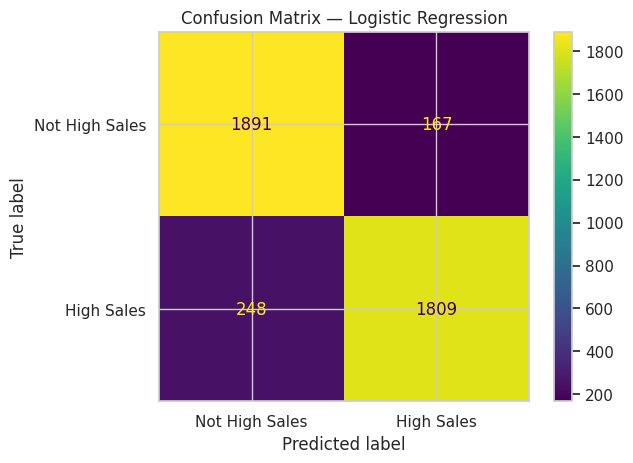

array([[1891,  167],
       [ 248, 1809]])

In [26]:
cm = confusion_matrix(y_clf, y_clf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not High Sales", "High Sales"]
)
disp.plot(values_format="d")
plt.title(f"Confusion Matrix — {best_clf_model_name}")
plt.show()

cm

In [ ]:
print(classification_report(y_clf, y_clf_pred, target_names=["Not High Sales", "High Sales"]))

### FP and FN interpretation

In this context:
- **False Positive (FP):** the model predicts a transaction as high-sales, but it is not.
- **False Negative (FN):** the model predicts a transaction as not high-sales, but it actually is high-sales.

A false negative may be more critical in a business context because the company may fail to identify an important high-value transaction or customer segment.  
However, the final importance depends on the business goal. If the company wants to avoid wasting resources on low-value transactions, false positives may also be costly.

## 12. Probability-Based Analysis

This section compares predicted probabilities for correct and incorrect predictions and helps identify high-confidence errors.

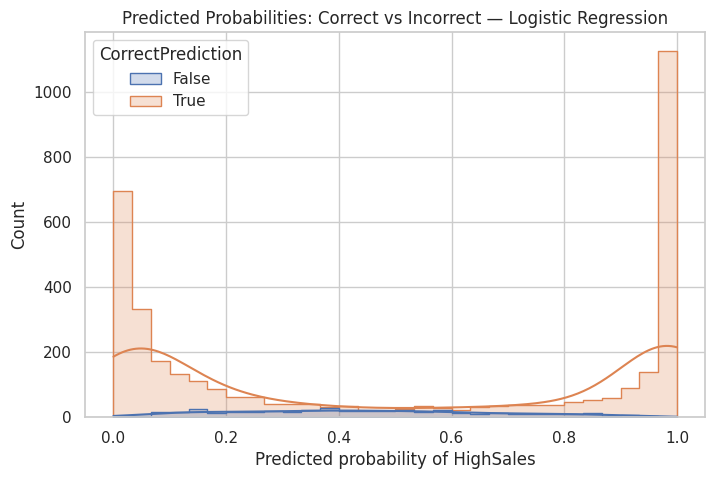

In [28]:
plt.figure(figsize=(8, 5))
sns.histplot(
    data=clf_error_df,
    x="PredictedProbability",
    hue="CorrectPrediction",
    bins=30,
    kde=True,
    element="step"
)
plt.title(f"Predicted Probabilities: Correct vs Incorrect — {best_clf_model_name}")
plt.xlabel("Predicted probability of HighSales")
plt.ylabel("Count")
plt.show()

In [29]:
# High-confidence errors: wrong predictions with probability close to 0 or 1
high_conf_errors = clf_error_df[
    (clf_error_df["ClassificationError"]) &
    ((clf_error_df["PredictedProbability"] >= 0.8) | (clf_error_df["PredictedProbability"] <= 0.2))
].copy()

high_conf_errors[[
    "Order ID", "Order Date", "Country", "Region", "Segment", "Category",
    "Sub-Category", "Product Name", "Quantity", "Cost", "Sales",
    "HighSales", "PredictedProbability", "PredictedClass"
]].head(20)

,Order ID,Order Date,Country,Region,Segment,Category,Sub-Category,Product Name,Quantity,Cost,Sales,HighSales,PredictedProbability,PredictedClass
22,23,2017-01-19,Italy,South,Home Office,Office Supplies,Binders,"Wilson Jones Binding Machine, Clear",3,6,145,1,0.020084,0
51,52,2017-02-09,Netherlands,Central,Corporate,Furniture,Furnishings,"Advantus Frame, Duo Pack",3,48,267,1,0.080498,0
107,108,2017-03-25,United Kingdom,North,Home Office,Office Supplies,Art,"Stanley Canvas, Easy-Erase",3,59,149,1,0.168030,0
160,161,2017-04-29,Italy,South,Consumer,Office Supplies,Binders,"Avery Binding Machine, Clear",3,93,145,1,0.129510,0
205,206,2017-05-27,Sweden,North,Corporate,Office Supplies,Envelopes,"Cameo Clasp Envelope, Recycled",11,32,46,0,0.803100,1
228,229,2017-06-06,Ireland,North,Consumer,Office Supplies,Storage,"Tenex File Cart, Single Width",2,0,135,1,0.031761,0
266,267,2017-06-17,France,Central,Home Office,Office Supplies,Supplies,"Acme Trimmer, Serrated",5,22,206,1,0.170978,0
278,279,2017-06-22,Italy,South,Consumer,Office Supplies,Art,"Stanley Canvas, Fluorescent",3,64,152,1,0.197972,0
284,285,2017-06-24,France,Central,Consumer,Office Supplies,Envelopes,"Cameo Mailers, with clear poly window",3,28,125,1,0.190476,0
286,287,2017-06-24,Netherlands,Central,Consumer,Office Supplies,Storage,"Tenex Lockers, Industrial",2,61,205,1,0.171021,0


### Probability interpretation

High-confidence errors are especially important because they indicate cases where the model was very sure but wrong.  
These cases may reveal systematic model failure, unusual observations, or insufficient features.

## 13. Classification Error as a Function of Features

This section compares feature distributions for correct and incorrect predictions.

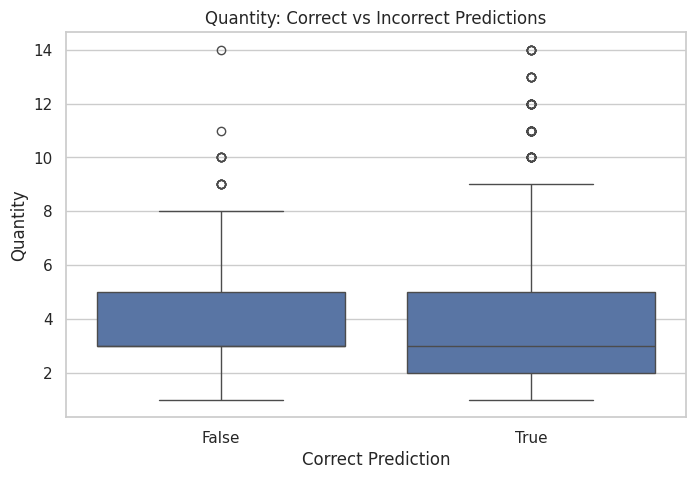

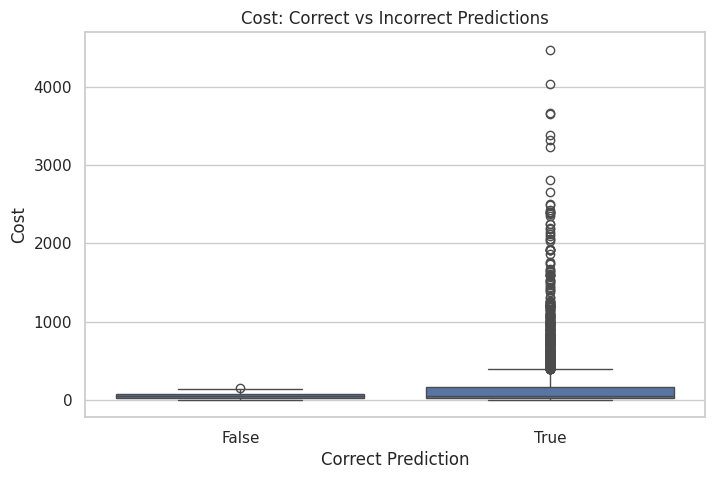

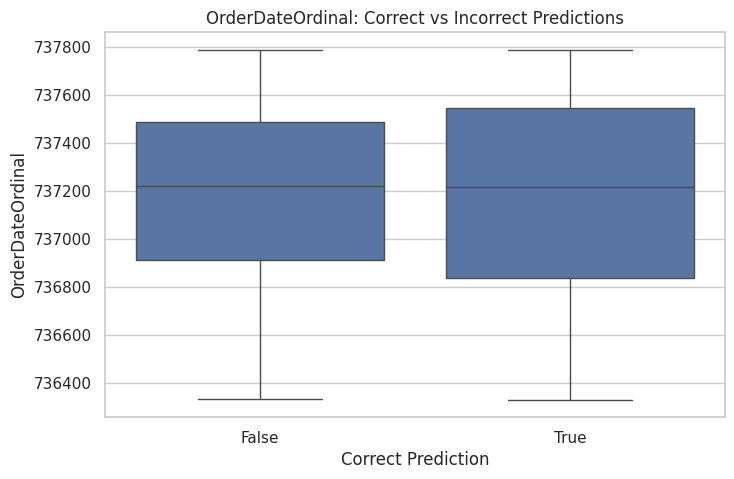

In [30]:
for col in ["Quantity", "Cost", "OrderDateOrdinal"]:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=clf_error_df, x="CorrectPrediction", y=col)
    plt.title(f"{col}: Correct vs Incorrect Predictions")
    plt.xlabel("Correct Prediction")
    plt.ylabel(col)
    plt.show()

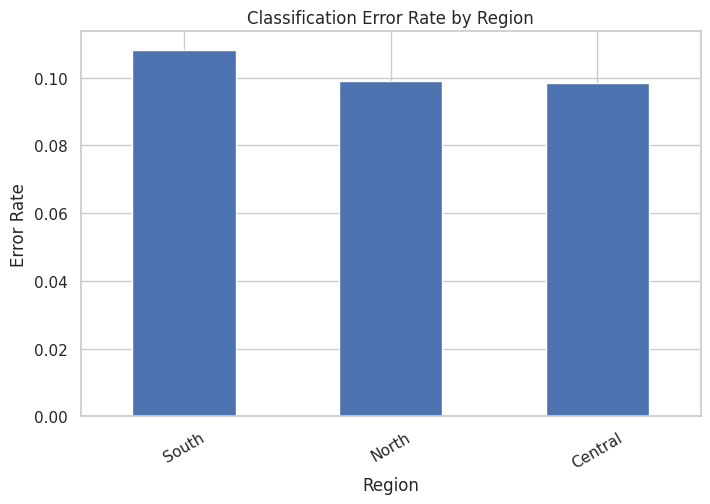

,Error Rate
Region,
South,0.108253
North,0.099052
Central,0.098522


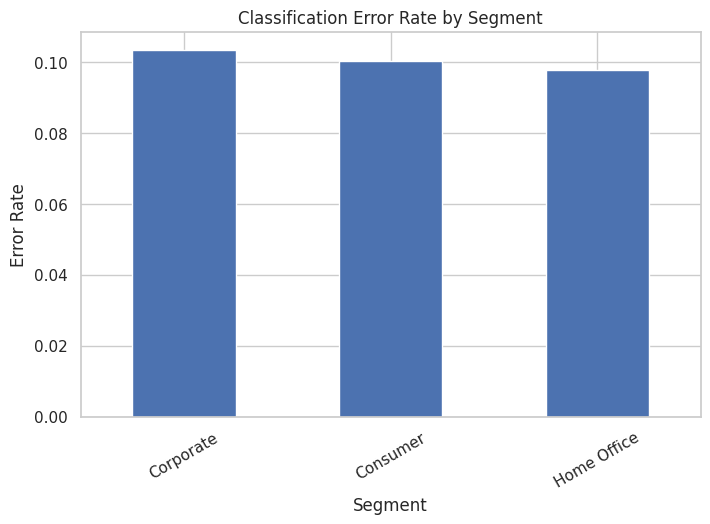

,Error Rate
Segment,
Corporate,0.103394
Consumer,0.100375
Home Office,0.097765


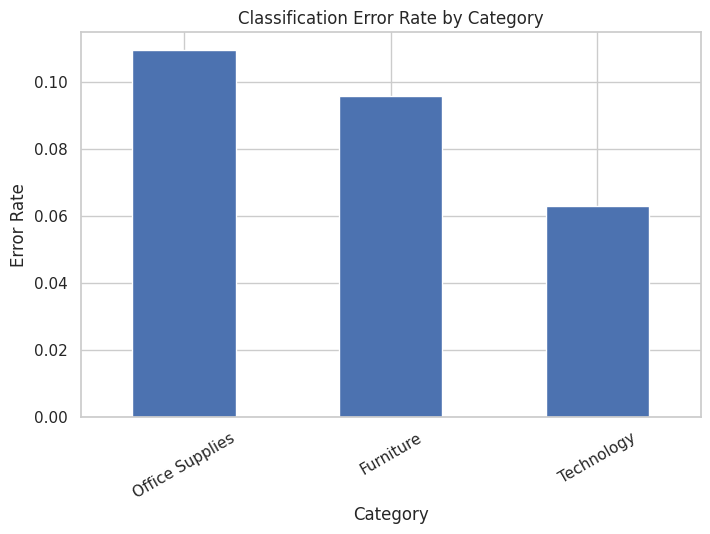

,Error Rate
Category,
Office Supplies,0.109441
Furniture,0.095725
Technology,0.063063


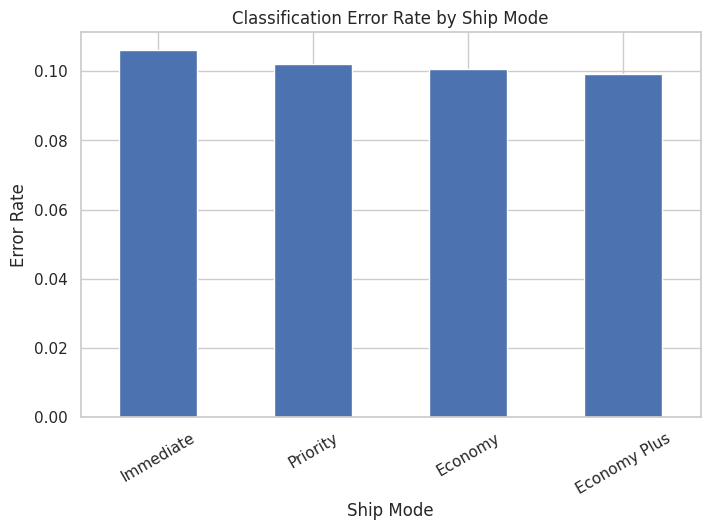

,Error Rate
Ship Mode,
Immediate,0.105991
Priority,0.102107
Economy,0.100696
Economy Plus,0.099045


In [31]:
for col in ["Region", "Segment", "Category", "Ship Mode"]:
    error_rate = clf_error_df.groupby(col)["ClassificationError"].mean().sort_values(ascending=False)

    plt.figure(figsize=(8, 5))
    error_rate.plot(kind="bar")
    plt.title(f"Classification Error Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Error Rate")
    plt.xticks(rotation=30)
    plt.show()

    display(error_rate.to_frame("Error Rate"))

### Feature-based error interpretation

If one region, segment, category, or shipping mode has a higher error rate, this suggests that the model fails systematically in that subgroup.  
Such findings can guide future feature engineering, data collection, or separate modeling strategies for difficult subpopulations.

## 14. Threshold Sensitivity Analysis

The assignment requires evaluating thresholds from 0.1 to 0.9 and computing:
- Precision
- Recall
- F1-score
- MCC
- AUC-ROC
- ROC curve

AUC-ROC does not depend on one threshold, so it is reported once for the probability scores.

In [32]:
thresholds = np.arange(0.1, 1.0, 0.1)
threshold_rows = []

for threshold in thresholds:
    pred_t = (y_clf_prob >= threshold).astype(int)

    threshold_rows.append({
        "Threshold": threshold,
        "Precision": precision_score(y_clf, pred_t, zero_division=0),
        "Recall": recall_score(y_clf, pred_t, zero_division=0),
        "F1": f1_score(y_clf, pred_t, zero_division=0),
        "MCC": matthews_corrcoef(y_clf, pred_t)
    })

threshold_df = pd.DataFrame(threshold_rows)
threshold_df

,Threshold,Precision,Recall,F1,MCC
0,0.1,0.703704,0.988333,0.822078,0.625772
1,0.2,0.790818,0.963053,0.868479,0.725812
2,0.3,0.843163,0.938260,0.888173,0.768700
3,0.4,0.883412,0.906174,0.894648,0.786897
4,0.5,0.915486,0.879436,0.897099,0.798916
5,0.6,0.941918,0.835683,0.885626,0.789232
6,0.7,0.959364,0.791930,0.867643,0.770251
7,0.8,0.976190,0.737482,0.840210,0.742065
8,0.9,0.992674,0.658726,0.791935,0.694379


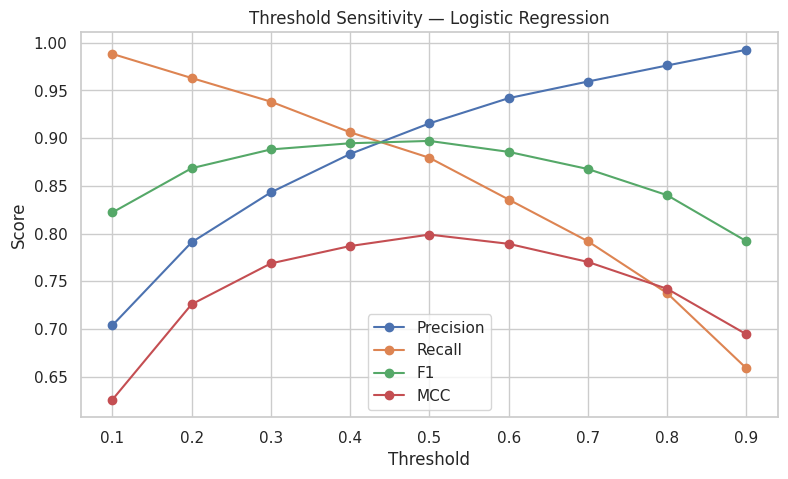

In [33]:
plt.figure(figsize=(9, 5))
plt.plot(threshold_df["Threshold"], threshold_df["Precision"], marker="o", label="Precision")
plt.plot(threshold_df["Threshold"], threshold_df["Recall"], marker="o", label="Recall")
plt.plot(threshold_df["Threshold"], threshold_df["F1"], marker="o", label="F1")
plt.plot(threshold_df["Threshold"], threshold_df["MCC"], marker="o", label="MCC")
plt.title(f"Threshold Sensitivity — {best_clf_model_name}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()

### Trade-off between FP and FN

Lower thresholds usually increase recall but may increase false positives.  
Higher thresholds usually increase precision but may increase false negatives.

A stable operating region is a range of thresholds where the performance metrics do not change sharply.  
An unstable region is a range where small threshold changes cause large metric changes.

## 15. Fβ-score as a Function of β

Fβ allows giving different importance to recall and precision:
- β > 1 gives more weight to recall.
- β < 1 gives more weight to precision.

In [ ]:
betas = np.arange(0.25, 3.25, 0.25)
fbeta_rows = []

for beta in betas:
    fbeta_rows.append({
        "Beta": beta,
        "F_beta": fbeta_score(y_clf, y_clf_pred, beta=beta, zero_division=0)
    })

fbeta_df = pd.DataFrame(fbeta_rows)
fbeta_df.head()

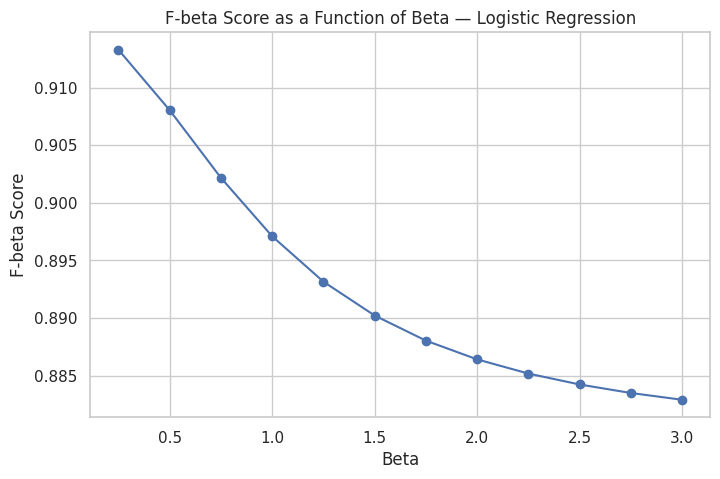

In [35]:
plt.figure(figsize=(8, 5))
plt.plot(fbeta_df["Beta"], fbeta_df["F_beta"], marker="o")
plt.title(f"F-beta Score as a Function of Beta — {best_clf_model_name}")
plt.xlabel("Beta")
plt.ylabel("F-beta Score")
plt.show()

## 16. ROC Curve and AUC-ROC

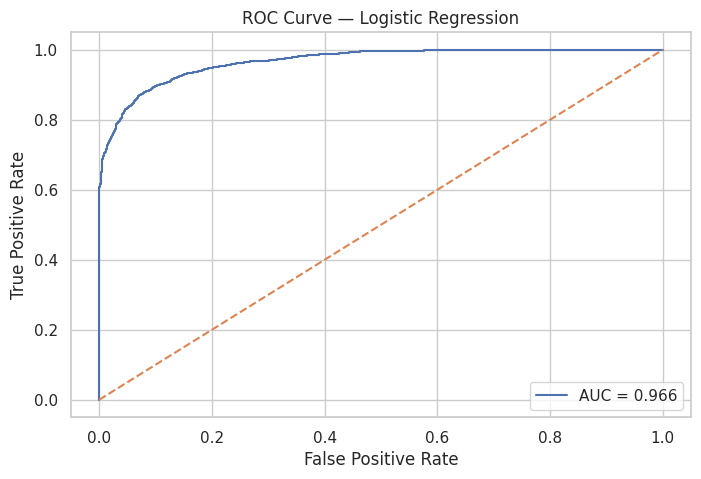

np.float64(0.9664526967811919)

In [36]:
auc = roc_auc_score(y_clf, y_clf_prob)
fpr, tpr, roc_thresholds = roc_curve(y_clf, y_clf_prob)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title(f"ROC Curve — {best_clf_model_name}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

auc

## 17. Classification Discussion

### Strengths and limitations
The classification models attempt to identify whether a transaction belongs to the high-sales class.  
The models may perform well when high-sales transactions have clear patterns in cost, quantity, product type, or customer segment.

### Key failure modes
Potential failures may occur when:
- Transactions are near the median threshold.
- Product types have overlapping sales patterns.
- Certain regions or segments are underrepresented.
- High-cardinality categories such as product names create sparse patterns.

### Model assumptions and performance
Logistic Regression assumes a relatively linear decision boundary.  
Tree-based models can capture more complex interactions but may be less interpretable.

### Recommendations
Future improvements may include:
- Additional business features such as discounts, customer history, or marketing campaigns.
- Better treatment of rare products.
- Separate models for different product categories.
- Hyperparameter tuning.
- More detailed temporal features.

# Part C — Final Reflection

## 18. Final Reflection

### 1. Where does the model fail most?

The model tends to fail most in observations that are unusual compared to the majority of the dataset.  
In regression, these are mainly transactions with very large absolute errors, often involving high sales values, expensive products, or rare combinations of category, country, and product.  
In classification, failures are especially important when the model is confident but wrong, or when errors are concentrated in a specific category, segment, region, or shipping mode.

### 2. Are failures due to data, model, or formulation?

The failures may come from all three sources:

**Data:**  
The dataset is limited to the available features. It does not include variables such as discounts, marketing campaigns, stock availability, customer history, or product margins beyond the existing columns. These missing factors may explain some errors.

**Model:**  
Linear models may fail when relationships are non-linear. Tree-based models can capture more complex patterns, but they may still struggle with rare products or sparse categories.

**Formulation:**  
The classification label `HighSales` is based on the median sales value. Transactions close to the threshold may be difficult to classify because the difference between classes may be small.

### 3. What improvements would you propose?

Possible improvements:
- Add more relevant business features.
- Use hyperparameter tuning.
- Treat rare categories more carefully.
- Analyze high-error subgroups separately.
- Consider separate models by category or segment.
- Use additional ensemble models such as Gradient Boosting.

### 4. What insights did you gain?

The main insight is that model evaluation should not rely only on one overall metric.  
A model can have good average performance but still fail systematically for certain subgroups or extreme observations.  
Error analysis helps reveal these weaknesses and provides a better understanding of the relationship between the data, the model, and the problem definition.